# Pronósticos

En este taller usaremos los modelos de series de tiempo lineales para hacer pronósticos de corto plazo de algunas series económicas

## Series

- PIB frecuencia anual, desde 1980
- PIB frecuencia trimestral, desde marzo 2005
- Tasa de desempleo, frecuencia mensual desde enero 2001
- TRM, frecuencia mensual desde enero 2000

## Procedimiento



In [1]:
library("readxl")
# Use the RAW url, not the github "blob" page
url <- "https://raw.githubusercontent.com/andvarga-eco/econometrics_finance/main/notebooks/data_forecast.xlsx"

# readxl cannot read straight from a URL, so download to a temp file first
tmp <- tempfile(fileext = ".xlsx")
download.file(url, destfile = tmp, mode = "wb")   # mode = "wb" is required on Windows

# Load the first sheet
pib_y <- read_excel(tmp, sheet = 1)
pib_q<-read_excel(tmp, sheet = 2)
td_m<-read_excel(tmp, sheet = 3)
trm_m<-read_excel(tmp, sheet = 4)

Warning message:
package ‘readxl’ was built under R version 4.5.3 
trying URL 'https://raw.githubusercontent.com/andvarga-eco/econometrics_finance/main/notebooks/data_forecast.xlsx'
Content type 'application/octet-stream' length 28532 bytes (27 KB)
downloaded 27 KB



Seguiremos el flujo de trabajo de [Forecasts principles and practice](https://otexts.com/fpp3/arima-r.html). 

In [2]:
library(fable)
library(tsibble)
library(dplyr)
library(ggtime)
library(feasts)
library(ggplot2)
library(tidyr)

Loading required package: fabletools


Warning messages:
1: package ‘fable’ was built under R version 4.5.3 
2: package ‘fabletools’ was built under R version 4.5.3 



Attaching package: ‘tsibble’

The following objects are masked from ‘package:base’:

    intersect, setdiff, union



Warning message:
package ‘tsibble’ was built under R version 4.5.3 



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Warning message:
package ‘dplyr’ was built under R version 4.5.3 
Warning message:
package ‘ggtime’ was built under R version 4.5.3 
Warning message:
package ‘feasts’ was built under R version 4.5.3 


### PIB anual

In [3]:
pib_y<-pib_y|>filter(date>1979)|>as_tsibble(index=date) # Convertimos en un objeto tsible

In [4]:
pib_y<-pib_y|>mutate(lpib=log(pib), dlpib=difference(lpib))

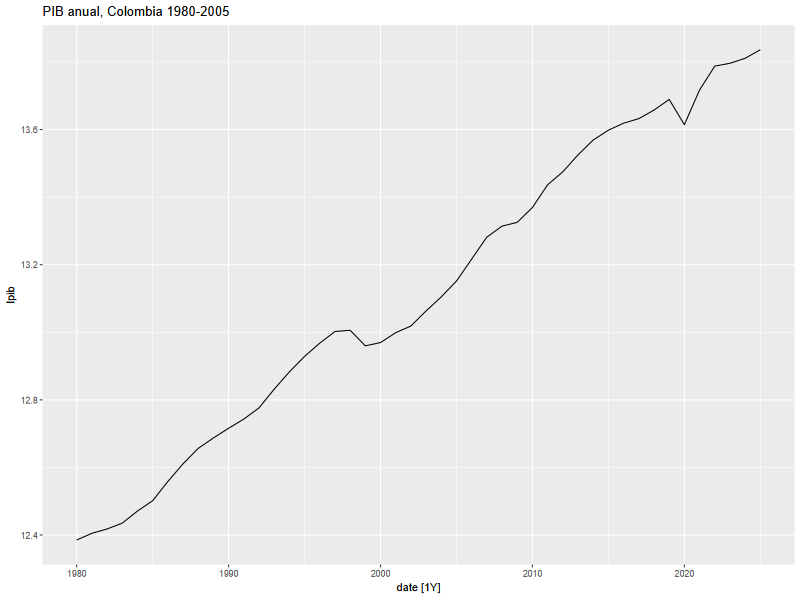

In [5]:
pib_y|>autoplot(lpib)+labs(title="PIB anual, Colombia 1980-2005")

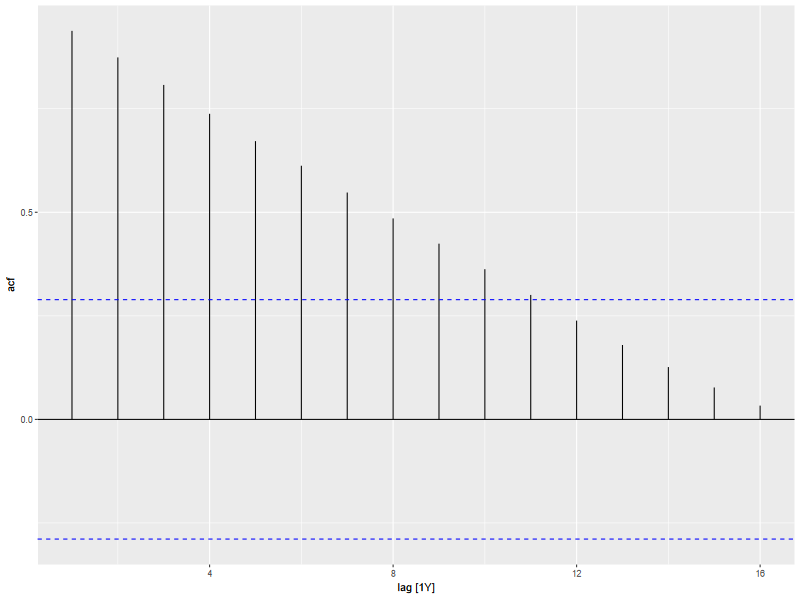

In [6]:
pib_y|>ACF(lpib)|>autoplot()

La serie en niveles no tiene evidencia de estacionariedad ni dependencia débil. Trabajamos con la serie en diferencias

Warning messages:
1: Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 1 row containing missing values or values outside the scale range (`geom_point()`). 


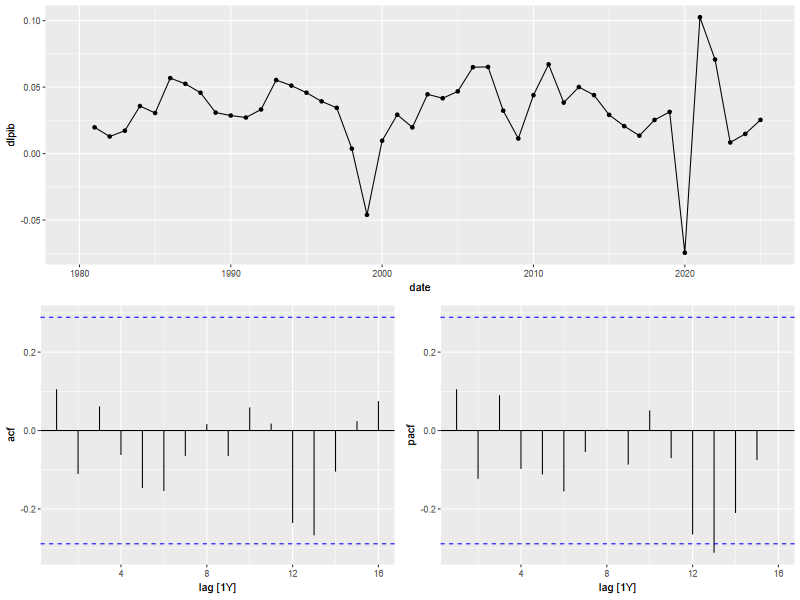

In [7]:
pib_y|>gg_tsdisplay(dlpib)

Las gráficas señalan que la serie en diferencias parece ser estacionaria y exhibe dependencia débil. Note que todas las autocorrelaciones son cero, al igual que las parciales, con lo cual no tenemos un criterio evidente para proponer un modelo ARMA en particular. Usaremos el algoritnmo de búsqueda de modelos con el algoritmo de búsqueda de Hyndman-Khandakar

In [8]:
Fcast_PIB<-pib_y|>
  model(dlpib_step=ARIMA(dlpib),
dlpib_search=ARIMA(dlpib, stepwise=FALSE))

In [9]:
print(Fcast_PIB)

# A mable: 1 x 2
              dlpib_step           dlpib_search
                 <model>                <model>
1 <ARIMA(0,0,0) w/ mean> <ARIMA(0,0,0) w/ mean>


In [10]:
tidy(Fcast_PIB)

# A tibble: 2 × 6
  .model       term     estimate std.error statistic  p.value
  <chr>        <chr>       <dbl>     <dbl>     <dbl>    <dbl>
1 dlpib_step   constant   0.0322   0.00416      7.76 7.82e-10
2 dlpib_search constant   0.0322   0.00416      7.76 7.82e-10

In [11]:
glance(Fcast_PIB)

# A tibble: 2 × 8
  .model         sigma2 log_lik   AIC  AICc   BIC ar_roots  ma_roots 
  <chr>           <dbl>   <dbl> <dbl> <dbl> <dbl> <list>    <list>   
1 dlpib_step   0.000777    97.3 -191. -190. -187. <cpl [0]> <cpl [0]>
2 dlpib_search 0.000777    97.3 -191. -190. -187. <cpl [0]> <cpl [0]>

El proceso automático coincide con el diagnóstico visual, pues propone un modelo ARMA(0,0)

Ahora examinamos los residuales

Warning messages:
1: Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 1 row containing missing values or values outside the scale range (`geom_point()`). 
3: Removed 1 row containing non-finite outside the scale range (`stat_bin()`). 
4: Removed 1 row containing missing values or values outside the scale range (`geom_rug()`). 


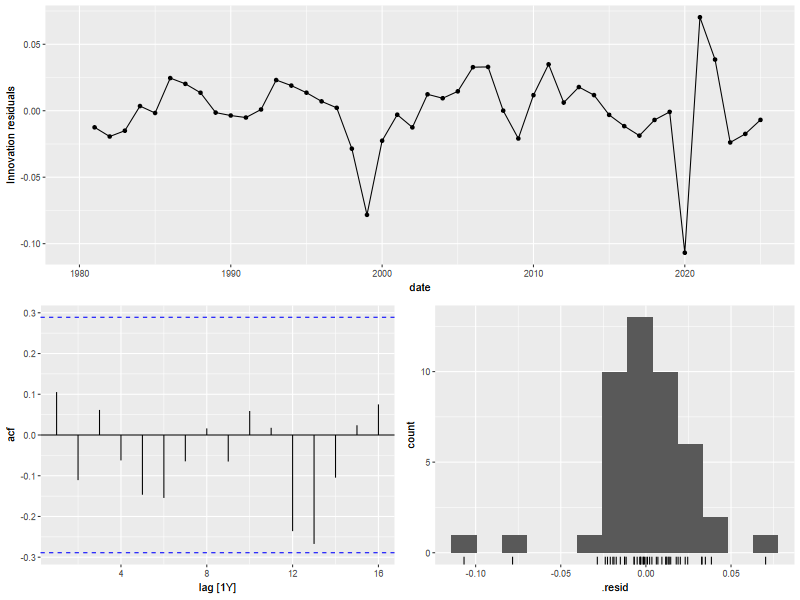

In [12]:
Fcast_PIB|>select(dlpib_step)|>gg_tsresiduals()

Los residuales son ruido blanco. Ahora hacemos el pronóstico

In [13]:
Fcast_PIB_values<-Fcast_PIB|>forecast(h=5)|>filter(.model=="dlpib_step")
print(Fcast_PIB_values)

# A fable: 5 x 4 [1Y]
# Key:     .model [1]
  .model      date             dlpib  .mean
  <chr>      <dbl>            <dist>  <dbl>
1 dlpib_step  2026 N(0.032, 0.00078) 0.0322
2 dlpib_step  2027 N(0.032, 0.00078) 0.0322
3 dlpib_step  2028 N(0.032, 0.00078) 0.0322
4 dlpib_step  2029 N(0.032, 0.00078) 0.0322
5 dlpib_step  2030 N(0.032, 0.00078) 0.0322


In [14]:
mean(pib_y$dlpib,na.rm=TRUE)

[1] 0.03224816

Warning message:
Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 


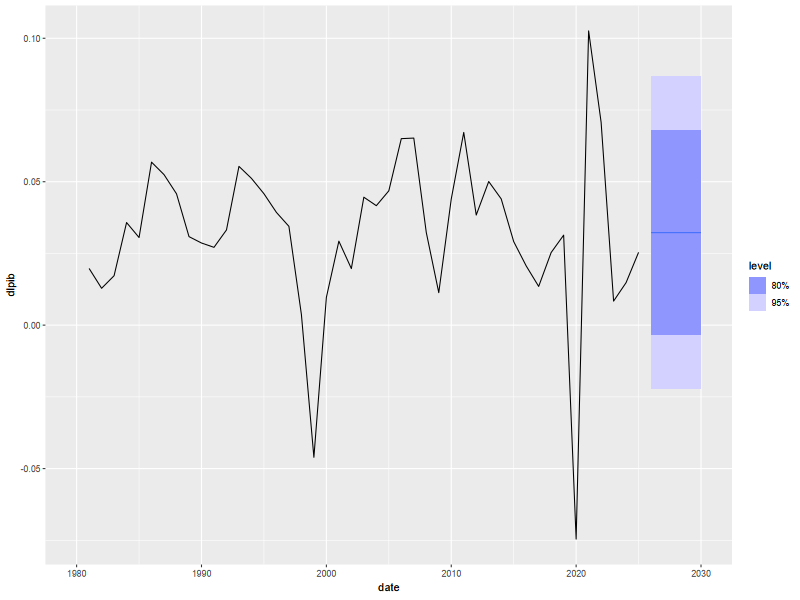

In [15]:
Fcast_PIB|>forecast(h=5)|>filter(.model=="dlpib_step")|>autoplot(pib_y)

Note que el pronóstico es la media incondicional de la variable a partir de h=1 ¿Por qué?

## Tasa de desempleo

In [16]:
td_m<-td_m|>mutate(month=yearmonth(date))|>as_tsibble(index=month) # Convertimos en un objeto tsible

In [17]:
td_m<-td_m|>mutate(dtd=difference(td_13))

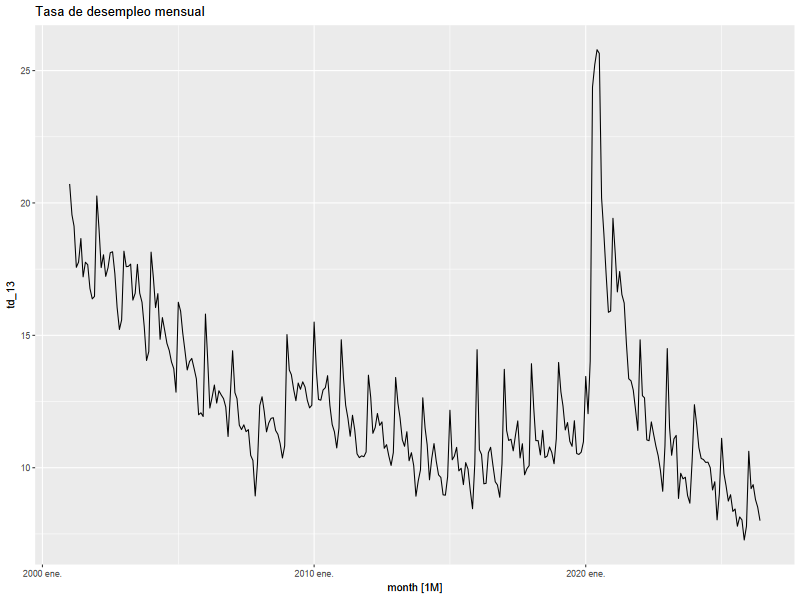

In [18]:
td_m|>autoplot(td_13)+labs(title="Tasa de desempleo mensual")

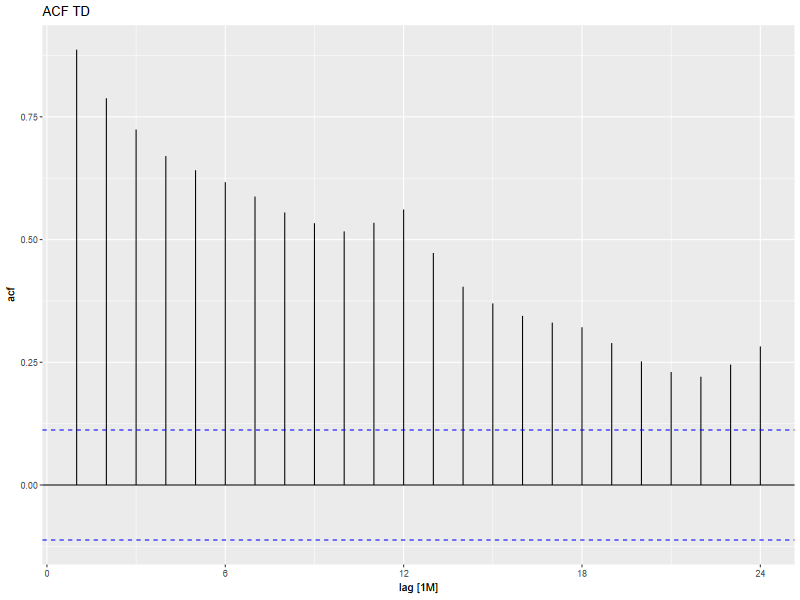

In [19]:
td_m|>ACF(td_13)|>autoplot()+labs(title="ACF TD")

Warning message:
Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 


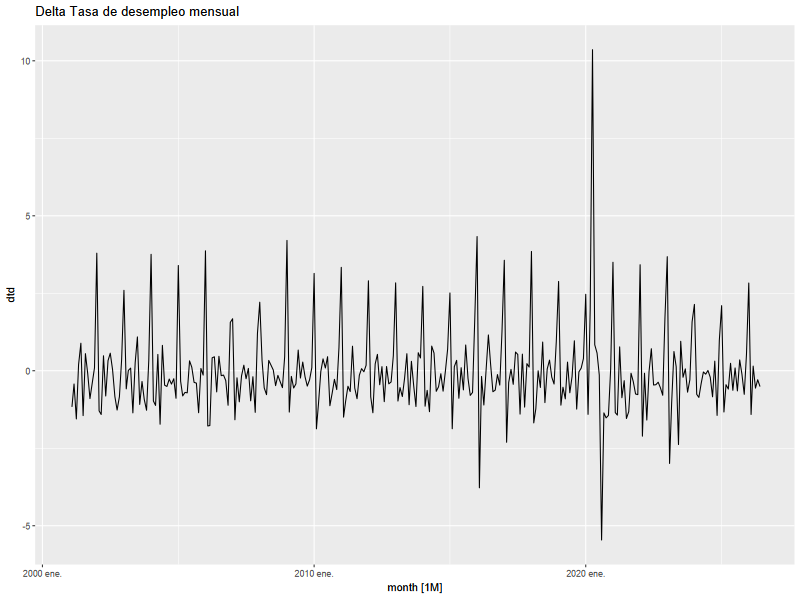

In [20]:
td_m|>autoplot(dtd)+labs(title="Delta Tasa de desempleo mensual")

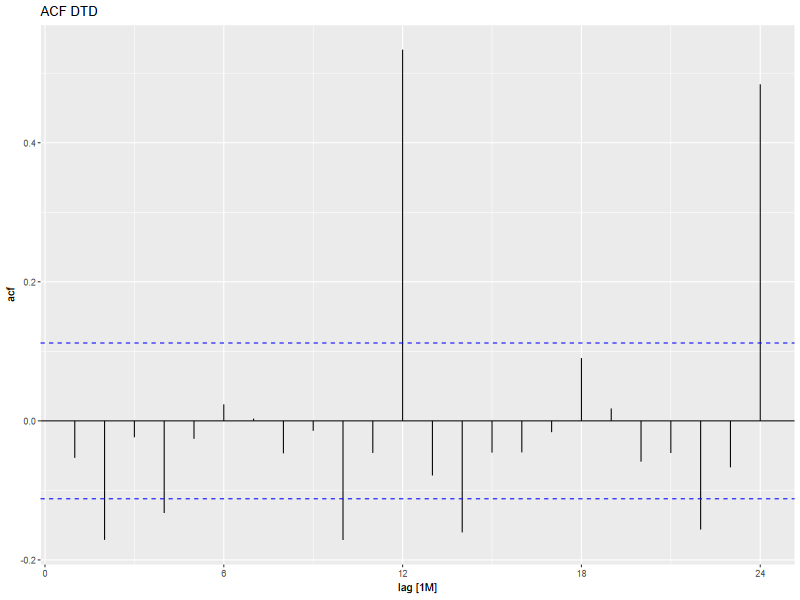

In [21]:
td_m|>ACF(dtd)|>autoplot()+labs(title="ACF DTD")

La serie en niveles no parece estacionaria ni con dependencia débil y exhibe un claro patrón estacional. La serie en diferencias parece estacionaria y muestra dependencia débil. El patrón estacional se evidencia en las autocorrelaciones de cada 12 rezagos. Al modelarla debería incluirse un ajuste por estacionalidad. Usaremos el proceso automatizado de ARIMA sobre la serie en niveles

In [22]:
Fcast_TD<-td_m|>
  model(td_step=ARIMA(td_13),
td_search=ARIMA(td_13, stepwise=FALSE))

In [23]:
print(Fcast_TD)

# A mable: 1 x 2
                    td_step                 td_search
                    <model>                   <model>
1 <ARIMA(0,1,0)(2,0,0)[12]> <ARIMA(0,1,4)(2,0,0)[12]>


El algoritmo sugiere dos modelos, ambos contienen un componente estacional multiplicativo y sugieren que la serie sea diferenciada. Se diferencian en que td_step no tiene términos AR ni MA, mientras que td_search sugiere un término MA(4)

In [24]:
tidy(Fcast_TD)

# A tibble: 8 × 6
  .model    term  estimate std.error statistic  p.value
  <chr>     <chr>    <dbl>     <dbl>     <dbl>    <dbl>
1 td_step   sar1   0.384      0.0537    7.14   6.71e-12
2 td_step   sar2   0.292      0.0545    5.36   1.66e- 7
3 td_search ma1   -0.0112     0.0578   -0.194  8.47e- 1
4 td_search ma2   -0.0712     0.0584   -1.22   2.24e- 1
5 td_search ma3    0.00406    0.0634    0.0640 9.49e- 1
6 td_search ma4   -0.181      0.0588   -3.08   2.25e- 3
7 td_search sar1   0.386      0.0543    7.11   8.40e-12
8 td_search sar2   0.285      0.0550    5.18   4.09e- 7

In [25]:
Fcast_TD_values<-Fcast_TD|>forecast(h=6)
print(Fcast_TD_values)

# A fable: 12 x 4 [1M]
# Key:     .model [2]
   .model         month       td_13 .mean
   <chr>          <mth>      <dist> <dbl>
 1 td_step    2026 jul.   N(8, 1.3)  8.04
 2 td_step    2026 ago. N(7.7, 2.5)  7.73
 3 td_step   2026 sept. N(7.6, 3.8)  7.62
 4 td_step    2026 oct.   N(7.7, 5)  7.66
 5 td_step    2026 nov.   N(7, 6.3)  6.95
 6 td_step    2026 dic. N(7.4, 7.5)  7.44
 7 td_search  2026 jul. N(7.9, 1.2)  7.93
 8 td_search  2026 ago. N(7.7, 2.4)  7.70
 9 td_search 2026 sept. N(7.6, 3.5)  7.61
10 td_search  2026 oct. N(7.7, 4.5)  7.73
11 td_search  2026 nov.   N(7, 5.2)  7.02
12 td_search  2026 dic. N(7.5, 5.9)  7.50


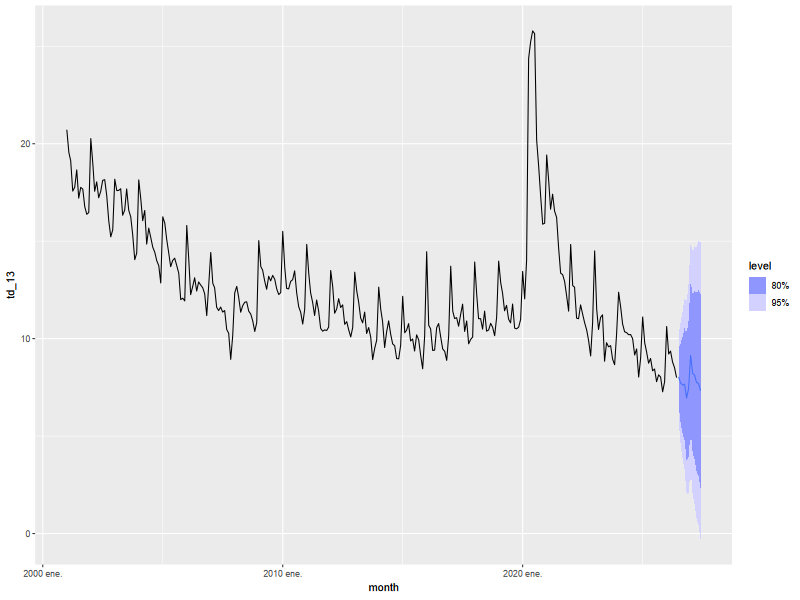

In [26]:
Fcast_TD|>forecast(h=12)|>filter(.model=="td_step")|>autoplot(td_m)

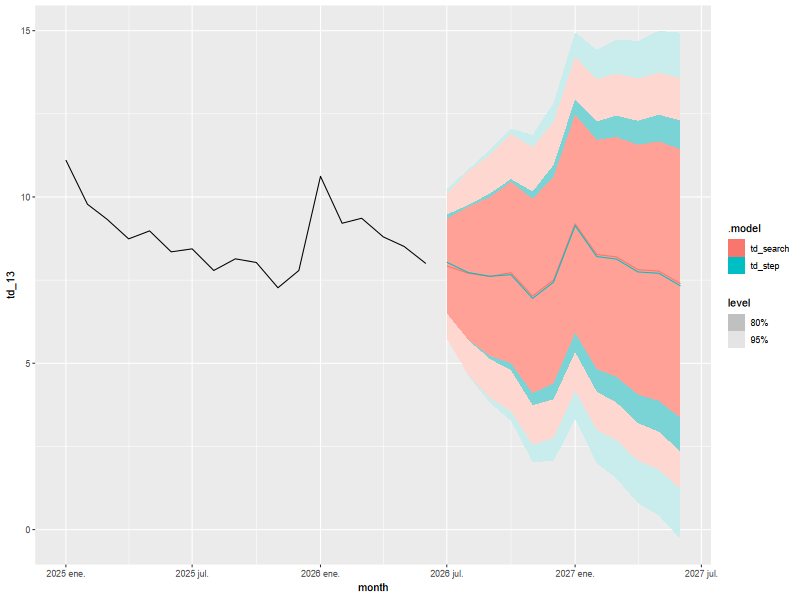

In [27]:
td_m25<-td_m|>filter_index("2025 jan"~ .)
Fcast_TD|>forecast(h=12)|>autoplot(td_m25)

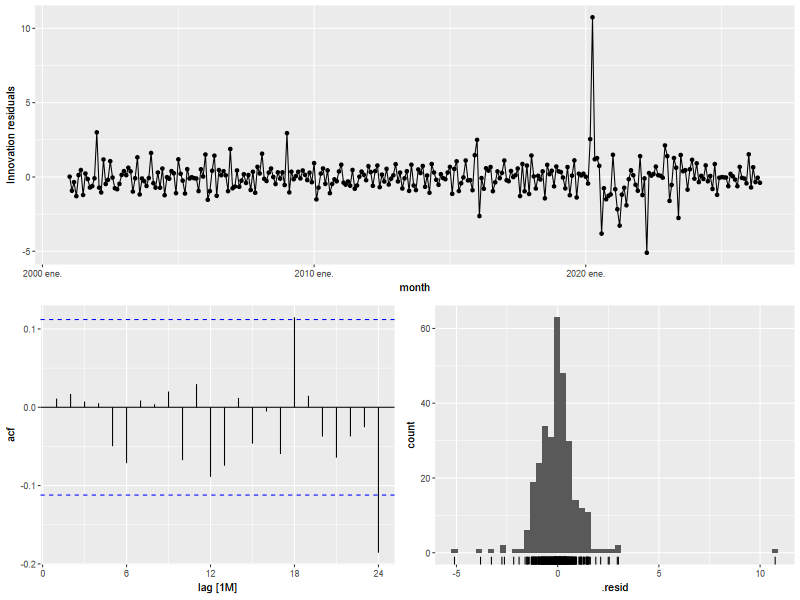

In [28]:
Fcast_TD|>select(td_search)|>gg_tsresiduals()

### Actividad

- Realice los pronósticos para el PIB trimestral, la TRM, y para una variable de su interés